In [6]:
import os
os.chdir("..")
import matplotlib.pyplot as plt
import numpy as np
from utils.data_utils import compute_trajectory_2


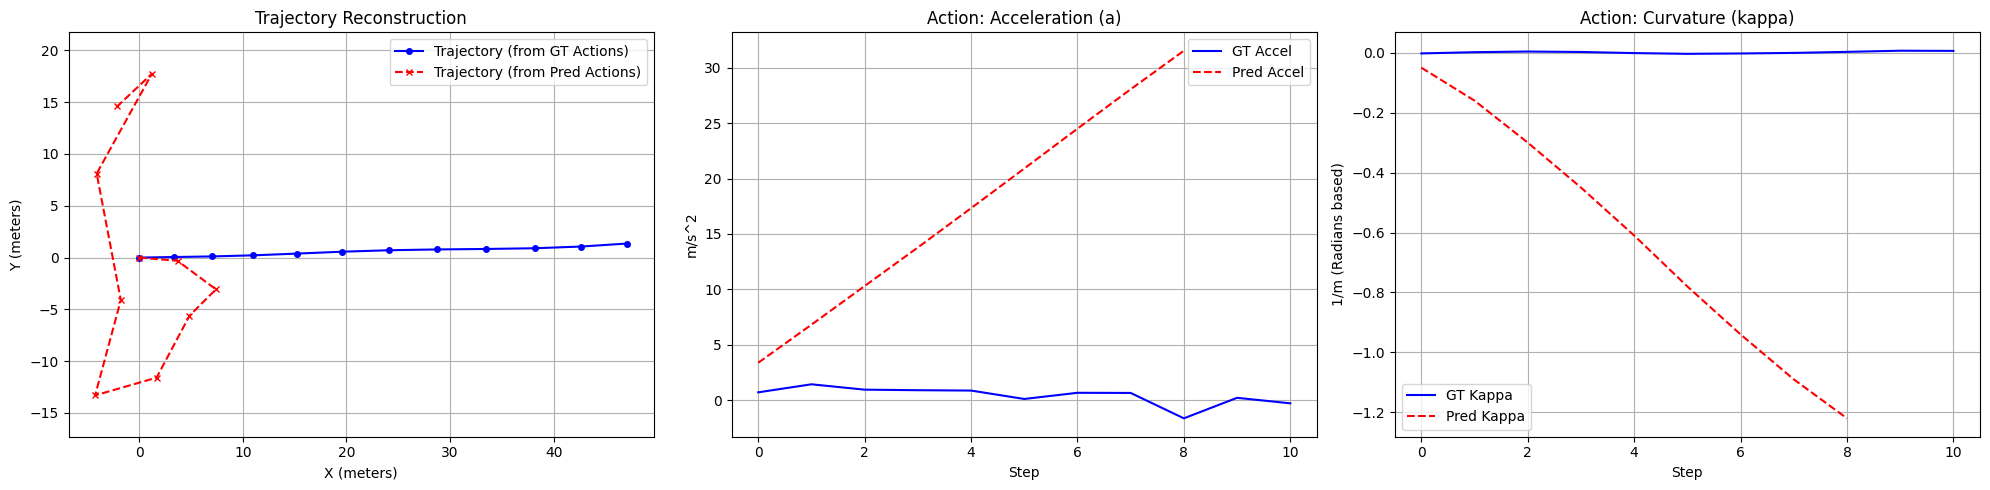

In [7]:
def visualize_inference_comparison(gt_actions, pred_actions, x0, y0, theta0, v0, dt):
    gt_act = np.array(gt_actions)
    pred_act = np.array(pred_actions)
    
    gt_traj = compute_trajectory_2(gt_act, x0, y0, theta0, v0, dt)
    pred_traj = compute_trajectory_2(pred_act, x0, y0, theta0, v0, dt)

    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(20, 5))

    ax1.plot(gt_traj[:, 0], gt_traj[:, 1], 'b-o', label='Trajectory (from GT Actions)', markersize=4)
    ax1.plot(pred_traj[:, 0], pred_traj[:, 1], 'r--x', label='Trajectory (from Pred Actions)', markersize=4)
    ax1.set_title("Trajectory Reconstruction")
    ax1.set_xlabel("X (meters)")
    ax1.set_ylabel("Y (meters)")
    ax1.axis('equal')
    ax1.grid(True)
    ax1.legend()

    ax2.plot(gt_act[:, 0], 'b-', label='GT Accel')
    ax2.plot(pred_act[:, 0], 'r--', label='Pred Accel')
    ax2.set_title("Action: Acceleration (a)")
    ax2.set_xlabel("Step")
    ax2.set_ylabel("m/s^2")
    ax2.grid(True)
    ax2.legend()

    ax3.plot(gt_act[:, 1], 'b-', label='GT Kappa')
    ax3.plot(pred_act[:, 1], 'r--', label='Pred Kappa')
    ax3.set_title("Action: Curvature (kappa)")
    ax3.set_xlabel("Step")
    ax3.set_ylabel("1/m (Radians based)")
    ax3.grid(True)
    ax3.legend()

    plt.tight_layout()
    plt.show()

gt_actions = [[0.6988, -0.0023], [1.4237, 0.0018], [0.9391, 0.0039], [0.8904, 0.0025], [0.8574, -0.0012], [0.0988, -0.0037], [0.6559, -0.0025], [0.6433, -0.0006], [-1.6507, 0.0029], [0.2033, 0.0067], [-0.2947, 0.0061]]
pred_actions = [[3.37, -0.05], [6.81, -0.16], [10.3, -0.3], [13.78, -0.45], [17.33, -0.61], [20.91, -0.78], [24.51, -0.94], [28.07, -1.09], [31.55, -1.22]]

v_init = 6.62
dt_val = 0.5

visualize_inference_comparison(gt_actions, pred_actions, 0, 0, 0.02, v_init, dt_val)